### Integrantes
- Carlos Alberto Castro
- John Alexis Cardona Zapata
- Kevin Velasquez Giraldo

# 1 - Contexto

## Banco Clientes

`Bancolombia` es una institución financiera líder en Colombia con presencia internacional y una amplia gama de servicios para personas, empresas y pymes.

![Logo](./assets/logo_Bancolombia.jpg)


Este proyecto es una iniciativa para Bancolombia S.A.S., especificamente para el entorno de cartera, la cual nos dio como objetivo principal para el Q4 del 2026, desarrollar un modelo predictivo que identifique a los clientes propensos a incurrir en mora de 30 días (Mora30) o mora de 60 días (Mora60) en el pago de sus créditos.

## Consultura

![Logo Orbis Insights](./assets/logo_Orbis_Insights.jpg)

**Orbis Insights** es una firma especializada en **análisis de información, inteligencia estratégica e investigación**, orientada a transformar información dispersa y compleja en conocimiento claro, relevante y accionable.

**Orbis Insights** representa una filosofía de trabajo basada en **ver el panorama completo, interpretar lo relevante y convertirlo en conocimiento para la toma de decisiones**.


# 2- Pregunta de Valor (Focalizado a predecir la mora)
¿ Se puede mejorar el sistema crediticio de Bancolombia mediante un modelo predictivo que identifique clientes con alta probabilidad de caer en mora (30 o 60 días), utilizando únicamente datos financieros ?



# 3- Políticas empresariales de calidad, consistencia y uso responsable

Las políticas se aplican a la base completa y se fundamentan en el diccionario de datos. `Ingresos` e `Ingresos_Totales` están expresados en **salarios mínimos legales mensuales vigentes (SMMLV)**. No se aplican umbrales monetarios absolutos sin especificar el año del SMMLV.

#### P1 — Completitud, unidades y faltantes
- `Mora30` y `Mora60` son etiquetas: los faltantes o valores distintos de 0 y 1 se excluyen del entrenamiento del objetivo correspondiente; nunca se imputan.
- `Ingresos`, `Ingresos_Totales` y `Gastos` deben corresponder al mismo periodo y unidad antes de compararse. Si `Gastos` está en pesos, convertirlo a SMMLV con el SMMLV del periodo.
- Un faltante en historial, deuda o créditos vigentes no significa automáticamente cero. Diferenciar “sin historial” de “dato no registrado” y conservar indicadores de imputación.

#### P2 — Fechas y formato
- `FDESEM` representa la fecha de desembolso. Convertirla con `pd.to_datetime(errors='coerce')`, validar fechas no convertibles y mantenerla como tipo fecha para ordenar.
- La presentación estándar de las fechas es `YYYY/MM/dd`.
- Documentar el periodo de observación de las variables y asegurar que los predictores estén disponibles antes de la fecha que define `Mora30` o `Mora60`.
- No usar `FDESEM` como predictor sin una justificación temporal; si se deriva antigüedad o cohorte, hacerlo sin revelar información futura.

#### P3 — Rangos y coherencia de variables
- `Ingresos`, `Ingresos_Totales` y `Gastos` deben ser numéricos y no negativos. Los negativos se marcan como inconsistencias para revisión.
- `Ingresos_Totales` normalmente debe ser mayor o igual que `Ingresos`. Si es menor, revisar si ambas variables tienen el mismo periodo, alcance y definición; no corregir automáticamente.
- `%Deuda Actual Sistema Financiero` debe estar entre 0 y 1; confirmar primero que no esté expresado como porcentaje de 0 a 100.
- `Antigüedad en el Sistema Financiero` debe ser un número de años no negativo y compatible con la fecha de desembolso y la fecha de consulta. Los valores extremos se investigan, no se descartan por un máximo arbitrario.
- `Numero de creditos vigentes` debe ser entero no negativo. Los valores no enteros, negativos o faltantes se reportan según su causa.
- `Mora60 = 1` implica `Mora30 = 1` únicamente cuando ambas etiquetas pertenecen al mismo periodo; las contradicciones se reportan y se excluyen del entrenamiento afectado.

#### P4 — Unicidad y alcance de la base
- `Cliente` es un identificador y no debe usarse como predictor.
- Verificar duplicados por `Cliente`. Antes de eliminar, determinar si representan créditos u observaciones diferentes; si son snapshots del mismo cliente, ordenar por `FDESEM` y conservar el registro correspondiente al periodo de modelado.
- Mantener la base original sin sobrescribirla y crear copias para limpieza, validación y modelado.

---

### Reglas de negocio

Las siguientes reglas generan validaciones o alertas para revisión. Una alerta no implica por sí sola rechazar al cliente ni eliminarlo del entrenamiento.

#### RN1 — Verificación de ingresos frente a gastos
- Verificar por separado `Ingresos > Gastos` y `Ingresos_Totales > Gastos`, siempre que las tres variables estén en la misma unidad y periodo. Los ingresos están en SMMLV.
- `Ingresos <= 0` o `Ingresos_Totales <= 0`: alerta de dato no válido o inconsistencia operativa.
- `Gastos > Ingresos`: alerta de flujo negativo respecto al ingreso principal.
- `Gastos > Ingresos_Totales`: alerta de flujo negativo respecto al ingreso total.
- Si `Ingresos_Totales < Ingresos`: alerta de inconsistencia entre componentes de ingreso; revisar definición, periodo y captura.
- Si `Gastos` está en pesos, convertir antes de comparar: `Gastos_SMLMV = Gastos / SMMLV_del_periodo`. Si no se conoce la unidad, no calcular las comparaciones y reportar la falta de metadatos.

#### RN2 — Índice de Compromiso de Ingresos (ICI)
- Calcular `ICI_principal = Gastos / Ingresos` e `ICI_total = Gastos / Ingresos_Totales` solo con denominadores positivos y unidades comparables.
- Clasificar cada índice como bajo (`<= 0.40`), medio (`0.40–0.70`) o alto (`> 0.70`). Son bandas analíticas internas y deben validarse con datos históricos; no se presentan como límites normativos.
- Si los dos índices difieren sustancialmente, revisar la composición de ingresos antes de emitir una alerta de riesgo.

#### RN3 — Endeudamiento actual
- `%Deuda Actual Sistema Financiero` es una proporción entre 0 y 1. Clasificar como bajo (`<= 0.30`), moderado (`0.30–0.60`), alto (`> 0.60`) y crítico (`> 0.90`) para priorizar revisión.
- Valores fuera de rango o con escala ambigua se reportan; no se truncan sin evidencia de error de captura.

#### RN4 — Número de créditos vigentes
- `1–3`: carga normal; `4–6`: seguimiento; `> 6`: alerta de concentración.
- Estas bandas no prueban por sí mismas sobreendeudamiento y deben contrastarse con ingresos, gastos, deuda y desempeño histórico.

#### RN5 — Antigüedad y experiencia financiera
- `Antigüedad en el Sistema Financiero = 0` puede representar ausencia de historial o un código de faltante. Confirmar su significado antes de aplicar un tratamiento conservador.
- Contrastar antigüedad con `FDESEM` y la fecha de consulta para detectar imposibles temporales.

#### RN6 — Perfil compuesto de alerta
- Marcar una alerta compuesta cuando el endeudamiento sea mayor a 0.60 y `ICI_total` sea mayor a 0.60, siempre que el índice sea calculable.
- Esta alerta complementa el modelo y activa revisión; no reemplaza la probabilidad, la calibración ni la revisión humana.

#### RN7 — Mora y créditos vigentes
- Mora con cero créditos vigentes es una alerta de consistencia temporal, no una contradicción automática: la mora puede corresponder a una obligación anterior o a otro periodo.
- Investigar fechas y definiciones antes de excluir el registro.

#### RN8 — Decisión responsable
- El modelo genera una probabilidad y una alerta, no una decisión crediticia aislada.
- Validar estabilidad temporal, calibración, explicabilidad y métricas por subgrupo; documentar motivo de la alerta, revisión humana y mecanismo de apelación.


#### P7 — Identificación del crédito y duplicados
- La base no contiene una columna explícita `IdCredito`. Por ello, la llave operativa mínima para verificar una observación es la combinación `Cliente` + `FDESEM`.
- Un mismo `Cliente` con la misma `FDESEM` en varias filas se marca como posible duplicado del mismo crédito o de la misma observación. Se debe revisar si los demás campos son idénticos antes de conservar una sola fila.
- Un mismo `Cliente` con diferentes valores de `FDESEM` no es automáticamente un duplicado: puede representar desembolsos, créditos o periodos distintos. Se conserva para análisis y se valida contra la fuente.
- Si se requiere identificar créditos individualmente, la fuente debe proporcionar un identificador de crédito. No se debe inventar uno a partir del índice de la fila.
- `FDESEM` se convierte a fecha, se valida y se presenta como `YYYY/MM/dd`; los registros sin cliente o sin fecha se reportan como problemas de identificación.

#### RN9 — Verificación de crédito, cliente y fecha
- Verificar nulos en `Cliente` y `FDESEM` antes de construir la llave operativa.
- Contabilizar duplicados exactos de `Cliente` + `FDESEM` y revisar diferencias en ingresos, gastos, estado de mora y demás atributos.
- Para duplicados confirmados, conservar el registro con información más completa o el que corresponda al periodo de modelado, documentando la decisión.
- No eliminar automáticamente registros de un mismo cliente con fechas diferentes; primero verificar si son créditos o desembolsos diferentes.


# Carga y preparación de datos

In [37]:
import pandas as pd
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

file_path = Path(r'.\DataBase\equipo_03_base_credito_ia.xlsx')
df = pd.read_excel(file_path)

# Paleta única reutilizada en limpieza y EDA.
AZUL = '#1A365D'
VERDE = '#2C7A7B'
GRIS = '#A0AEC0'
TURQUESA = '#4FD1C5'
PALETA = [AZUL, VERDE, GRIS, TURQUESA]
MAPA_CORRELACION = LinearSegmentedColormap.from_list(
    'correlacion', [AZUL, GRIS, TURQUESA]
)

print(f'Base cargada: {df.shape[0]:,} filas y {df.shape[1]:,} columnas')

Base cargada: 1,215 filas y 28 columnas


# Limpieza de datos

In [38]:
import numpy as np
import pandas as pd

# Limpieza conservadora según las políticas; df original no se modifica.
df_antes = df.copy()
df_limpio = df.copy()

columnas_numericas = df_limpio.select_dtypes(include='number').columns.tolist()
for columna in columnas_numericas:
    df_limpio[columna] = pd.to_numeric(df_limpio[columna], errors='coerce')
if 'FDESEM' in df_limpio:
    df_limpio['FDESEM'] = pd.to_datetime(df_limpio['FDESEM'], errors='coerce')

# Valores fuera de dominio: se marcan como faltantes, sin imputar ni truncar.
columnas_no_negativas = [
    'Ingresos', 'Ingresos_Totales', 'Gastos',
    'Antigüedad en el Sistema Financiero', 'Numero de creditos vigentes',
]
for columna in columnas_no_negativas:
    if columna in df_limpio:
        df_limpio.loc[df_limpio[columna] < 0, columna] = np.nan

if '%Deuda Actual Sistema Financiero' in df_limpio:
    deuda = df_limpio['%Deuda Actual Sistema Financiero']
    df_limpio.loc[~deuda.between(0, 1), '%Deuda Actual Sistema Financiero'] = np.nan

if 'Numero de creditos vigentes' in df_limpio:
    creditos = df_limpio['Numero de creditos vigentes']
    df_limpio.loc[creditos.notna() & (creditos % 1 != 0), 'Numero de creditos vigentes'] = np.nan

# Etiquetas inválidas quedan como faltantes para excluirlas al entrenar, nunca se imputan.
for objetivo in ['Mora30', 'Mora60']:
    if objetivo in df_limpio:
        df_limpio.loc[~df_limpio[objetivo].isin([0, 1]), objetivo] = np.nan

resumen_limpieza = pd.DataFrame({
    'Columna': df_antes.columns,
    'Nulos_antes': [df_antes[columna].isna().sum() for columna in df_antes.columns],
    'Nulos_despues': [df_limpio[columna].isna().sum() for columna in df_antes.columns],
    'Distintos_antes': [df_antes[columna].nunique(dropna=True) for columna in df_antes.columns],
    'Distintos_despues': [df_limpio[columna].nunique(dropna=True) for columna in df_antes.columns],
})
resumen_limpieza['Estado'] = np.where(
    (resumen_limpieza['Nulos_antes'] != resumen_limpieza['Nulos_despues'])
    | (resumen_limpieza['Distintos_antes'] != resumen_limpieza['Distintos_despues']),
    'AFECTADA',
    'SIN CAMBIOS',
)

if {'Cliente', 'FDESEM'}.issubset(df_limpio.columns):
    llave = df_limpio['Cliente'].notna() & df_limpio['FDESEM'].notna()
    duplicados_cliente_fecha = df_limpio.duplicated(['Cliente', 'FDESEM'], keep=False) & llave
else:
    duplicados_cliente_fecha = pd.Series(False, index=df_limpio.index)

print('=== Limpieza de datos: antes y después ===')
print(f'Filas: {len(df_antes):,} -> {len(df_limpio):,}')
print(f'Columnas: {df_antes.shape[1]:,} -> {df_limpio.shape[1]:,}')
print(f'Celdas nulas: {df_antes.isna().sum().sum():,} -> {df_limpio.isna().sum().sum():,}')
print(f'Duplicados Cliente + FDESEM reportados: {duplicados_cliente_fecha.sum():,}')

columnas_afectadas = resumen_limpieza[resumen_limpieza['Estado'] == 'AFECTADA']
print(f'\n=== Columnas afectadas ({len(columnas_afectadas)}) ===')
if columnas_afectadas.empty:
    print('Ninguna columna cambió.')
else:
    print(columnas_afectadas.to_string(index=False))

graficos_generados = False

=== Limpieza de datos: antes y después ===
Filas: 1,215 -> 1,215
Columnas: 28 -> 28
Celdas nulas: 123 -> 134
Duplicados Cliente + FDESEM reportados: 14

=== Columnas afectadas (2) ===
                         Columna  Nulos_antes  Nulos_despues  Distintos_antes  Distintos_despues   Estado
                          FDESEM            0              0              481                434 AFECTADA
%Deuda Actual Sistema Financiero            0             11             1156               1145 AFECTADA


# Análisis Exploratorio de Datos (EDA)

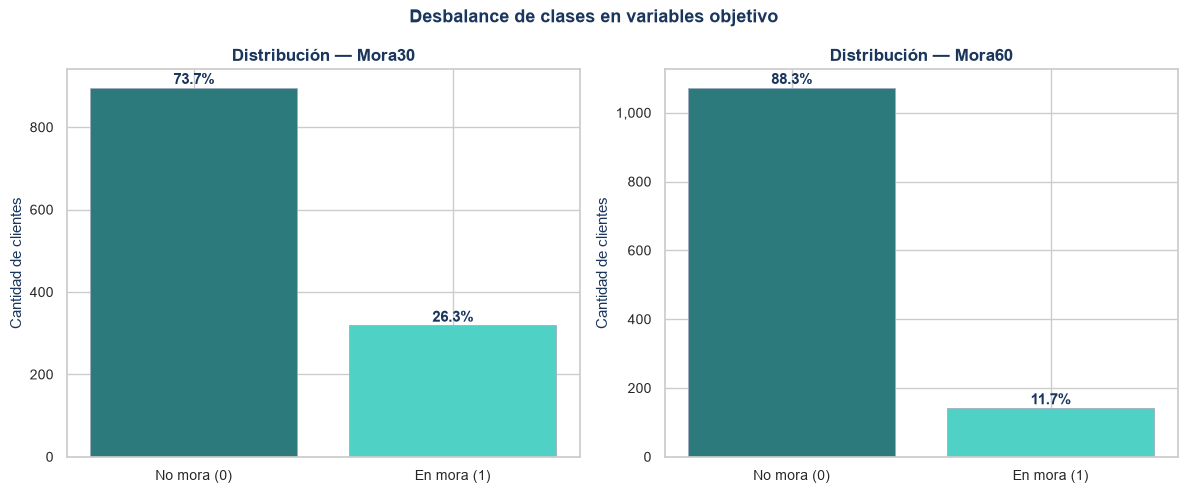

In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

TARGETS = ['Mora30', 'Mora60']
df_eda = df_limpio.copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target in zip(axes, TARGETS):
    counts = df_eda[target].value_counts().sort_index()
    pcts = counts / counts.sum() * 100
    bars = ax.bar(
        ['No mora (0)', 'En mora (1)'], counts.values,
        color=[VERDE, TURQUESA], edgecolor=GRIS, linewidth=0.6,
    )
    for bar, pct in zip(bars, pcts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.01,
            f'{pct:.1f}%', ha='center', fontsize=11,
            fontweight='bold', color=AZUL,
        )
    ax.set_title(f'Distribución — {target}', fontsize=12, fontweight='bold', color=AZUL)
    ax.set_ylabel('Cantidad de clientes', color=AZUL)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
fig.suptitle('Desbalance de clases en variables objetivo', fontsize=13, fontweight='bold', color=AZUL)
plt.tight_layout()
plt.show()

# 3- Datos (metadatos)

### Análisis de sesgo/discriminación por columna

| Columna | Razón de exclusión |
|---|---|
| `Cliente` | Solo identificador, sin valor predictivo |
| `Género` | Variable protegida — discriminación directa por género |
| `Edad` | Variable protegida — discriminación por edad |
| `Estado_Civil` | Proxy de discriminación (ej. soltero vs casado) |
| `Nivel_Academico` | Proxy de estatus socioeconómico |
| `Tipo_Vivienda` | Proxy de nivel socioeconómico |
| `REGCONS` | Discriminación geográfica/étnica |
| `PersonasCargo` | Puede discriminar familias numerosas |
| `OCUPACIÓN` | Riesgo de sesgo laboral/social |
| `TIPCONTRATO` | Discriminación por tipo de contrato |
| `SECTOR` | Sesgo sectorial que puede correlacionar con demografía |
| `Segmento` | Definido internamente por el banco, puede heredar sesgos históricos |
| `FDESEM` | Fecha de desembolso — no es característica del cliente |
| `Calificación Superfinanciera` | Puede ya incorporar Mora30/Mora60 → riesgo de leakage |
| `CalificaciónSistema Financiero` | Score que puede codificar mora pasada → riesgo de leakage |
| `MoraMaxima 12 meses` | Historial de mora → alta probabilidad de leakage con la variable objetivo |
| `Experiencia Financiera` | Bajo poder predictivo aislado y poca granularidad (binaria 0/1) |

### Columnas seleccionadas (máximo 5) — menor sesgo, mayor objetividad financiera

| # | Columna | Justificación |
|---|---|---|
| 1 | `Ingresos_Totales` | Capacidad de pago total del cliente — dato financiero objetivo |
| 2 | `Gastos` | Compromisos mensuales — mide presión sobre el ingreso disponible |
| 3 | `%Deuda Actual Sistema Financiero` | Ratio de endeudamiento actual — indicador directo de riesgo financiero |
| 4 | `Antigüedad en el Sistema Financiero` | Años con historial crediticio — mide madurez financiera sin revelar mora |
| 5 | `Numero de creditos vigentes` | Carga crediticia activa — indicador de capacidad de gestión de deuda |

 > **Criterios aplicados:** (1) variables puramente financieras, sin características demográficas protegidas; (2) sin proxy de raza, género, religión o estrato; (3) sin riesgo evidente de leakage con `Mora30`/`Mora60`; (4) todas numéricas, lo que evita sesgos de codificación en variables categóricas.

# 4- EDA (Análisis exploratorio)

# 5- Análisis descriptivo


In [17]:
import pandas as pd
from pathlib import Path

file_path = Path(r'.\DataBase\equipo_03_base_credito_ia.xlsx')
df = pd.read_excel(file_path)

# FDESEM se conserva como fecha para ordenar y validar.
df['FDESEM'] = pd.to_datetime(df['FDESEM'], errors='coerce')

print(f'Fechas válidas: {df["FDESEM"].notna().sum():,}')
print(f'Fechas no válidas o faltantes: {df["FDESEM"].isna().sum():,}')

vista = df.head().copy()
vista['FDESEM'] = vista['FDESEM'].dt.strftime('%Y/%m/%d')
display(vista)

,Cliente,Mora30,Mora60,Segmento,SECTOR,REGCONS,FDESEM,Ingresos,PersonasCargo,Gastos,...,Tipo_Vivienda,Calificación Superfinanciera,CalificaciónSistema Financiero,MoraMaxima 12 meses,%Deuda Actual Sistema Financiero,MoraMaxima 12 meses.1,Experiencia Financiera,Antigüedad en el Sistema Financiero,Numero de creditos vigentes,Semaforo_Comite_Riesgo
0,141,1,0,MDO,PERSONAS NATURALES,ESPECIAL,2013-10-02 00:00:00,1.280000,0.0,0.409700,...,FAMILIAR,A,857,47,0.282593,47,1,20,0,BAJO
1,46,0,0,MDO,PERSONAS NATURALES,NORTE,2013-05-08 00:00:00,1.200000,1.0,0.308000,...,FAMILIAR,B,666,0,0.351257,0,1,5,0,BAJO
2,121,0,0,MDO,PERSONAS NATURALES,OCCIDENTE,2015-02-23 00:00:00,1.244000,0.0,0.386000,...,FAMILIAR,A,836,30,0.573720,30,0,60,0,BAJO
3,596,0,0,STD,PERSONAS NATURALES,OCCIDENTE,2014-12-16 00:00:00,0.764196,0.0,0.367636,...,FAMILIAR,A,809,17,0.701327,17,1,3,0,MEDIO
4,651,0,0,MDO,PERSONAS NATURALES,OCCIDENTE,2015-10-28 00:00:00,1.125000,0.0,0.308000,...,ALQUILADA,A,778,0,0.919884,0,0,0,0,BAJO


In [23]:
import pandas as pd
from pathlib import Path

file_path = Path(r'.\DataBase\equipo_03_base_credito_ia.xlsx')
df = pd.read_excel(file_path)
df['FDESEM'] = pd.to_datetime(df['FDESEM'], errors='coerce')

TARGET = ['Mora30', 'Mora60']
EXCLUIR_IDENTIFICADORES = ['Cliente']

# Se conserva la base completa; la selección final de predictores se hará
# después de revisar tipos, disponibilidad temporal y leakage.
df_modelo = df.copy()

print('=== Estructura completa de la base ===')
print(f'Registros: {len(df_modelo):,} | Columnas: {df_modelo.shape[1]}')
print(df_modelo.dtypes)
print('\n=== Valores nulos por columna ===')
print(df_modelo.isnull().sum())

=== Estructura completa de la base ===
Registros: 1,215 | Columnas: 28
Cliente                                         int64
Mora30                                          int64
Mora60                                          int64
Segmento                                          str
SECTOR                                            str
REGCONS                                           str
FDESEM                                 datetime64[us]
Ingresos                                      float64
PersonasCargo                                 float64
Gastos                                        float64
TIEMPACTIVAÑO                                   int64
OCUPACIÓN                                         str
TIPCONTRATO                                       str
Edad                                            int64
Estado_Civil                                      str
Género                                            str
Ingresos_Totales                              float64
Nivel_Acade

In [24]:
import pandas as pd
import numpy as np

# --- Validación general de reglas de negocio ---
# Ingresos e Ingresos_Totales están expresados en SMMLV.
GASTOS_EN_SMMLV = False
SMMLV_DEL_PERIODO = None

rn = pd.DataFrame(index=df_modelo.index)

def serie_numerica(nombre):
    return pd.to_numeric(df_modelo[nombre], errors='coerce')

ingresos = serie_numerica('Ingresos')
ingresos_totales = serie_numerica('Ingresos_Totales')
gastos = serie_numerica('Gastos')

if GASTOS_EN_SMMLV:
    gastos_smlmv = gastos
elif SMMLV_DEL_PERIODO is not None and SMMLV_DEL_PERIODO > 0:
    gastos_smlmv = gastos / SMMLV_DEL_PERIODO
else:
    gastos_smlmv = pd.Series(np.nan, index=df_modelo.index)

unidades_comparables = gastos_smlmv.notna()

# RN1: validar ingresos principales, ingresos totales y gastos.
rn['RN1_ingreso_no_positivo'] = ingresos <= 0
rn['RN1_ingreso_total_no_positivo'] = ingresos_totales <= 0
rn['RN1_gasto_mayor_ingreso'] = (
    unidades_comparables & ingresos.notna() & (gastos_smlmv > ingresos)
)
rn['RN1_gasto_mayor_ingreso_total'] = (
    unidades_comparables & ingresos_totales.notna() & (gastos_smlmv > ingresos_totales)
)
rn['RN1_total_menor_principal'] = (
    ingresos.notna() & ingresos_totales.notna() & (ingresos_totales < ingresos)
)

# RN2: ICI frente al ingreso principal y al ingreso total.
rn['ICI_principal'] = gastos_smlmv / ingresos.where(ingresos > 0)
rn['ICI_total'] = gastos_smlmv / ingresos_totales.where(ingresos_totales > 0)
for nombre_ici in ['ICI_principal', 'ICI_total']:
    rn[f'RN2_riesgo_{nombre_ici}'] = pd.cut(
        rn[nombre_ici],
        bins=[-np.inf, 0.40, 0.70, np.inf],
        labels=['Bajo', 'Medio', 'Alto'],
    )

# RN3: nivel de endeudamiento.
deuda = serie_numerica('%Deuda Actual Sistema Financiero')
rn['RN3_nivel_deuda'] = pd.cut(
    deuda,
    bins=[-np.inf, 0.30, 0.60, 0.90, np.inf],
    labels=['Bajo', 'Moderado', 'Alto', 'Crítico'],
)

# RN4: concentración de créditos.
creditos = serie_numerica('Numero de creditos vigentes')
rn['RN4_carga_crediticia'] = pd.cut(
    creditos,
    bins=[-np.inf, 3, 6, np.inf],
    labels=['Normal', 'Seguimiento', 'Alerta'],
)

# RN5: historial financiero.
antiguedad = serie_numerica('Antigüedad en el Sistema Financiero')
rn['RN5_sin_historial'] = antiguedad == 0

# RN6: perfil compuesto, calculable solo con ICI_total válido.
rn['RN6_riesgo_compuesto'] = (deuda > 0.60) & (rn['ICI_total'] > 0.60)

# RN7: alerta temporal, no exclusión automática.
rn['RN7_mora_sin_creditos'] = (
    ((df_modelo['Mora30'] == 1) | (df_modelo['Mora60'] == 1))
    & (creditos == 0)
)

# RN9: llave operativa para verificar crédito/observación.
# No existe IdCredito en la fuente: Cliente + FDESEM identifica el registro.
fecha_desembolso = pd.to_datetime(df_modelo['FDESEM'], errors='coerce')
cliente_faltante = df_modelo['Cliente'].isna()
fecha_faltante = fecha_desembolso.isna()
llave_cliente_fecha = pd.DataFrame({
    'Cliente': df_modelo['Cliente'],
    'FDESEM': fecha_desembolso,
})
duplicado_cliente_fecha = llave_cliente_fecha.duplicated(
    subset=['Cliente', 'FDESEM'], keep=False
) & ~cliente_faltante & ~fecha_faltante
cliente_multiples_fechas = (
    df_modelo.assign(FDESEM_validada=fecha_desembolso)
    .groupby('Cliente')['FDESEM_validada']
    .transform('nunique') > 1
)
rn['RN9_cliente_fecha_duplicada'] = duplicado_cliente_fecha
rn['RN9_cliente_multiples_fechas'] = cliente_multiples_fechas

alertas = {
    'RN1 — Ingreso no positivo': rn['RN1_ingreso_no_positivo'].sum(),
    'RN1 — Ingreso total no positivo': rn['RN1_ingreso_total_no_positivo'].sum(),
    'RN1 — Gastos > Ingresos': rn['RN1_gasto_mayor_ingreso'].sum(),
    'RN1 — Gastos > Ingresos_Totales': rn['RN1_gasto_mayor_ingreso_total'].sum(),
    'RN1 — Ingreso total < Ingreso': rn['RN1_total_menor_principal'].sum(),
    'RN5 — Sin historial financiero': rn['RN5_sin_historial'].sum(),
    'RN6 — Riesgo compuesto': rn['RN6_riesgo_compuesto'].sum(),
    'RN7 — Revisar mora y periodo': rn['RN7_mora_sin_creditos'].sum(),
    'RN9 — Cliente + FDESEM duplicado': rn['RN9_cliente_fecha_duplicada'].sum(),
    'RN9 — Cliente con múltiples fechas': rn['RN9_cliente_multiples_fechas'].sum(),
}

print('=== Alertas de reglas de negocio ===')
for regla, total in alertas.items():
    print(f'  {regla}: {total:,} registros ({total / len(df_modelo) * 100:.1f}%)')

print('\n=== Verificación de identificación ===')
print(f'Clientes faltantes: {cliente_faltante.sum():,}')
print(f'FDESEM faltante o inválida: {fecha_faltante.sum():,}')
print('Formato de presentación de FDESEM: YYYY/MM/dd')

if not unidades_comparables.any():
    print('\n=== Comparación de ingresos y gastos no disponible ===')
    print('Confirme si Gastos está en SMMLV o proporcione SMMLV_DEL_PERIODO.')
else:
    print('\n=== Distribución ICI principal ===')
    print(rn['RN2_riesgo_ICI_principal'].value_counts().sort_index().to_string())
    print('\n=== Distribución ICI total ===')
    print(rn['RN2_riesgo_ICI_total'].value_counts().sort_index().to_string())

print('\n=== Nivel de endeudamiento ===')
print(rn['RN3_nivel_deuda'].value_counts().sort_index().to_string())

print('\n=== Carga crediticia ===')
print(rn['RN4_carga_crediticia'].value_counts().sort_index().to_string())

=== Alertas de reglas de negocio ===
  RN1 — Ingreso no positivo: 28 registros (2.3%)
  RN1 — Ingreso total no positivo: 0 registros (0.0%)
  RN1 — Gastos > Ingresos: 0 registros (0.0%)
  RN1 — Gastos > Ingresos_Totales: 0 registros (0.0%)
  RN1 — Ingreso total < Ingreso: 971 registros (79.9%)
  RN5 — Sin historial financiero: 407 registros (33.5%)
  RN6 — Riesgo compuesto: 0 registros (0.0%)
  RN7 — Revisar mora y periodo: 292 registros (24.0%)
  RN9 — Cliente + FDESEM duplicado: 14 registros (1.2%)
  RN9 — Cliente con múltiples fechas: 0 registros (0.0%)

=== Verificación de identificación ===
Clientes faltantes: 0
FDESEM faltante o inválida: 0
Formato de presentación de FDESEM: YYYY/MM/dd

=== Comparación de ingresos y gastos no disponible ===
Confirme si Gastos está en SMMLV o proporcione SMMLV_DEL_PERIODO.

=== Nivel de endeudamiento ===
RN3_nivel_deuda
Bajo        116
Moderado    201
Alto        504
Crítico     394

=== Carga crediticia ===
RN4_carga_crediticia
Normal         121

# 4- EDA (Análisis Exploratorio de Datos)


In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=0.9)

# El EDA utiliza la información ya limpiada.
df = df_limpio.copy()

EXCLUIR = ['Cliente', 'FDESEM']
TARGETS = ['Mora30', 'Mora60']

cols_num = [c for c in df.select_dtypes(include='number').columns
            if c not in EXCLUIR + TARGETS]
cols_cat = [c for c in df.select_dtypes(include='object').columns
            if c not in EXCLUIR]

ncols = 3
nrows = int(np.ceil(len(cols_num) / ncols))

print(f"Cuantitativas ({len(cols_num)}): {cols_num}")
print(f"Cualitativas  ({len(cols_cat)}): {cols_cat}")
print(f"Targets       ({len(TARGETS)}): {TARGETS}")

Cuantitativas (12): ['Ingresos', 'PersonasCargo', 'Gastos', 'TIEMPACTIVAÑO', 'Edad', 'Ingresos_Totales', 'MoraMaxima 12 meses', '%Deuda Actual Sistema Financiero', 'MoraMaxima 12 meses.1', 'Experiencia Financiera', 'Antigüedad en el Sistema Financiero', 'Numero de creditos vigentes']
Cualitativas  (12): ['Segmento', 'SECTOR', 'REGCONS', 'OCUPACIÓN', 'TIPCONTRATO', 'Estado_Civil', 'Género', 'Nivel_Academico', 'Tipo_Vivienda', 'Calificación Superfinanciera', 'CalificaciónSistema Financiero', 'Semaforo_Comite_Riesgo']
Targets       (2): ['Mora30', 'Mora60']


## 4.1 — Variables Cuantitativas: Distribución (histograma + KDE)


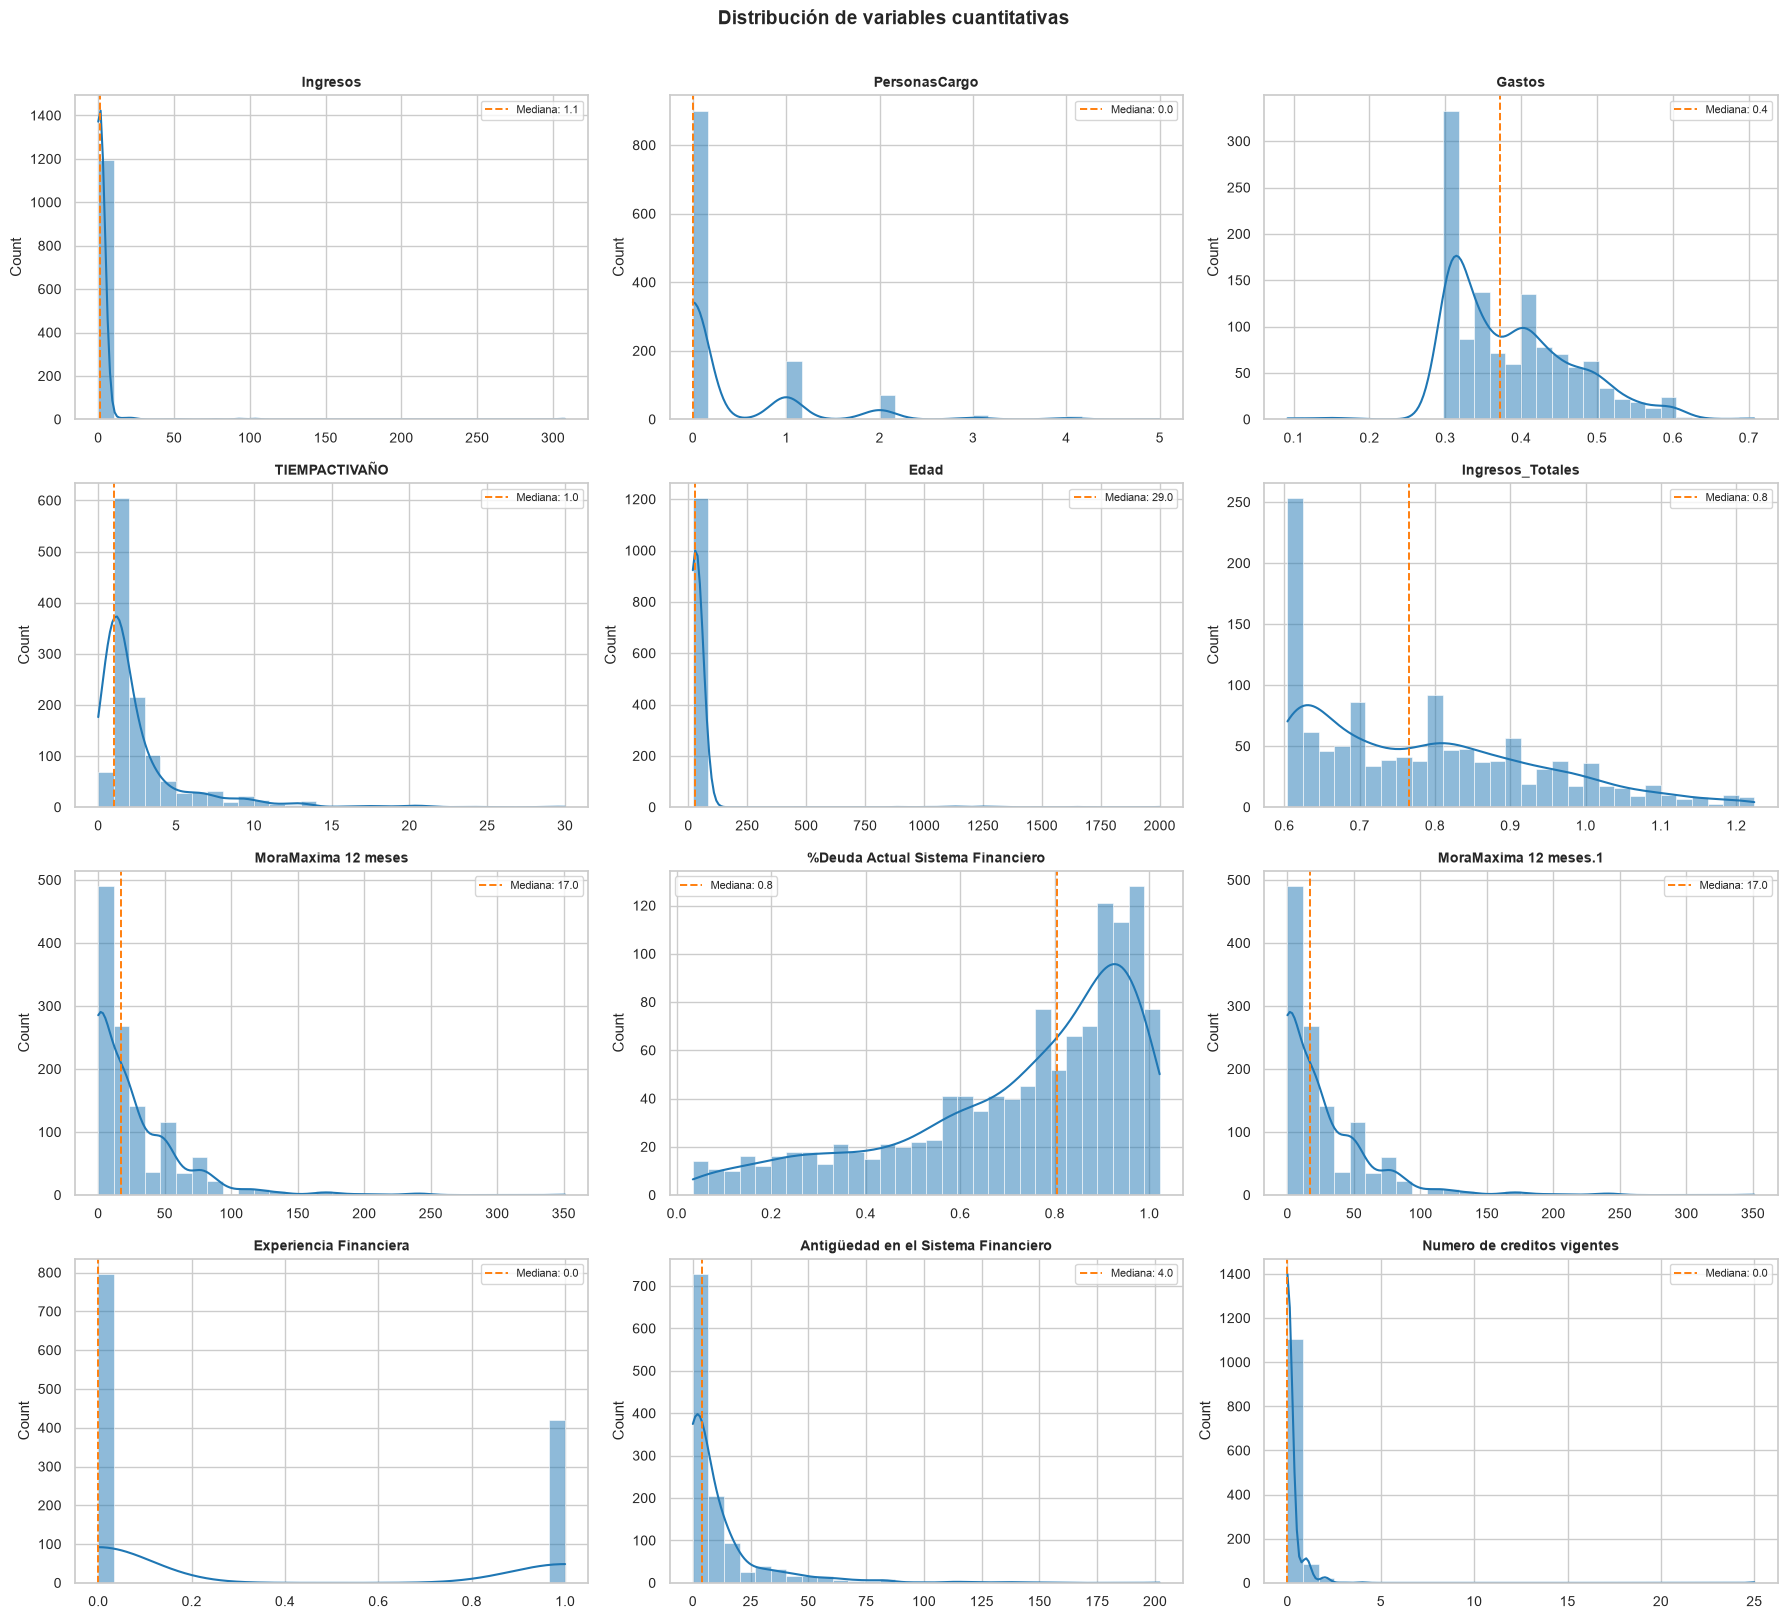

In [5]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    ax = axes[i]
    data = df[col].dropna()
    sns.histplot(data, kde=True, ax=ax, color=AZUL, bins=30, edgecolor=GRIS, linewidth=0.4)
    ax.set_title(col, fontsize=10, fontweight='bold', color=AZUL)
    ax.set_xlabel('')
    ax.axvline(data.median(), color=TURQUESA, linestyle='--', linewidth=1.4, label=f'Mediana: {data.median():.1f}')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de variables cuantitativas', fontsize=14, fontweight='bold', color=AZUL, y=1.01)
plt.tight_layout()
plt.show()

## 4.2 — Variables Cuantitativas: Boxplots (detección de outliers)


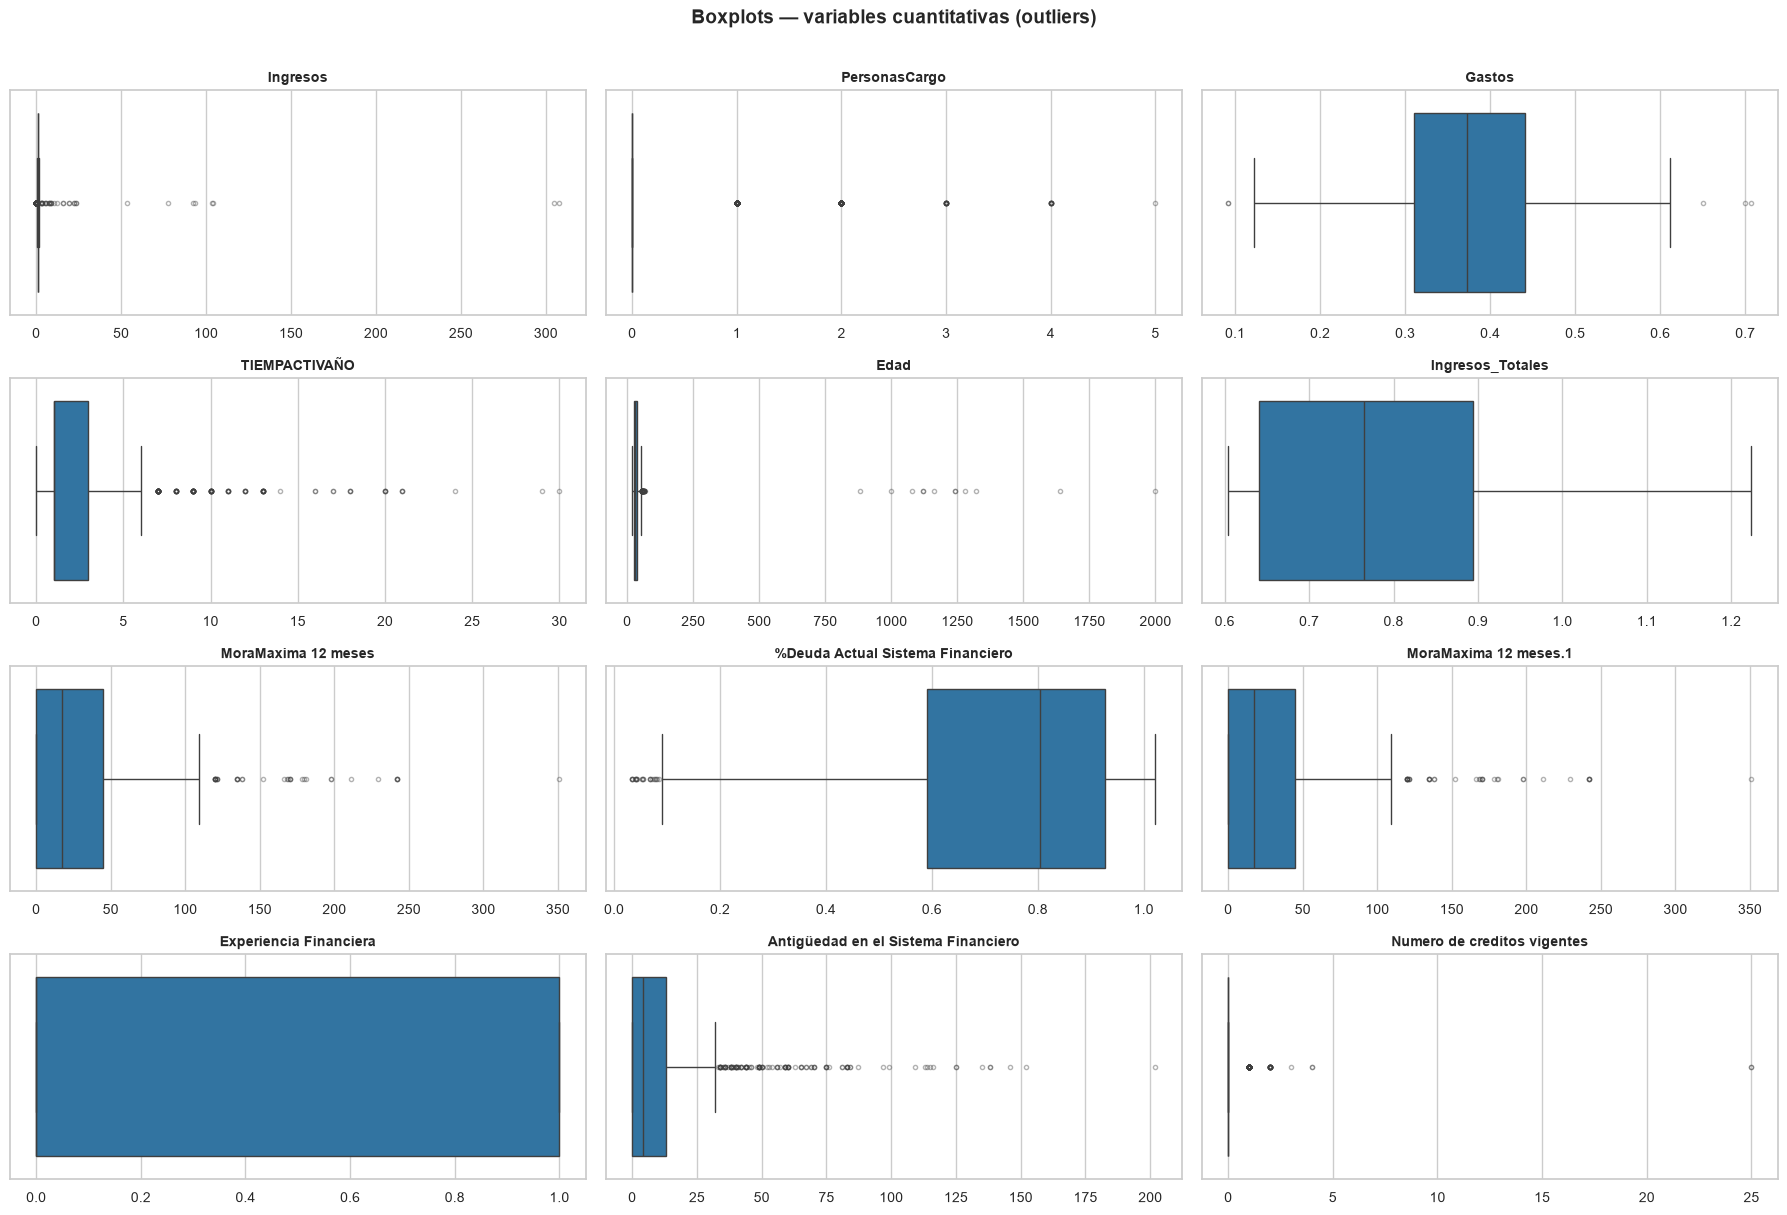

In [6]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    ax = axes[i]
    sns.boxplot(
        x=df[col].dropna(),
        ax=ax,
        color=VERDE,
        flierprops=dict(
            marker='o',
            markersize=3,
            markerfacecolor=TURQUESA,
            markeredgecolor=AZUL,
            alpha=0.4,
        ),
    )
    ax.set_title(col, fontsize=10, fontweight='bold', color=AZUL)
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots — variables cuantitativas (outliers)', fontsize=14, fontweight='bold', color=AZUL, y=1.01)
plt.tight_layout()
plt.show()

## 4.3 — Variables Cualitativas: Frecuencia de categorías


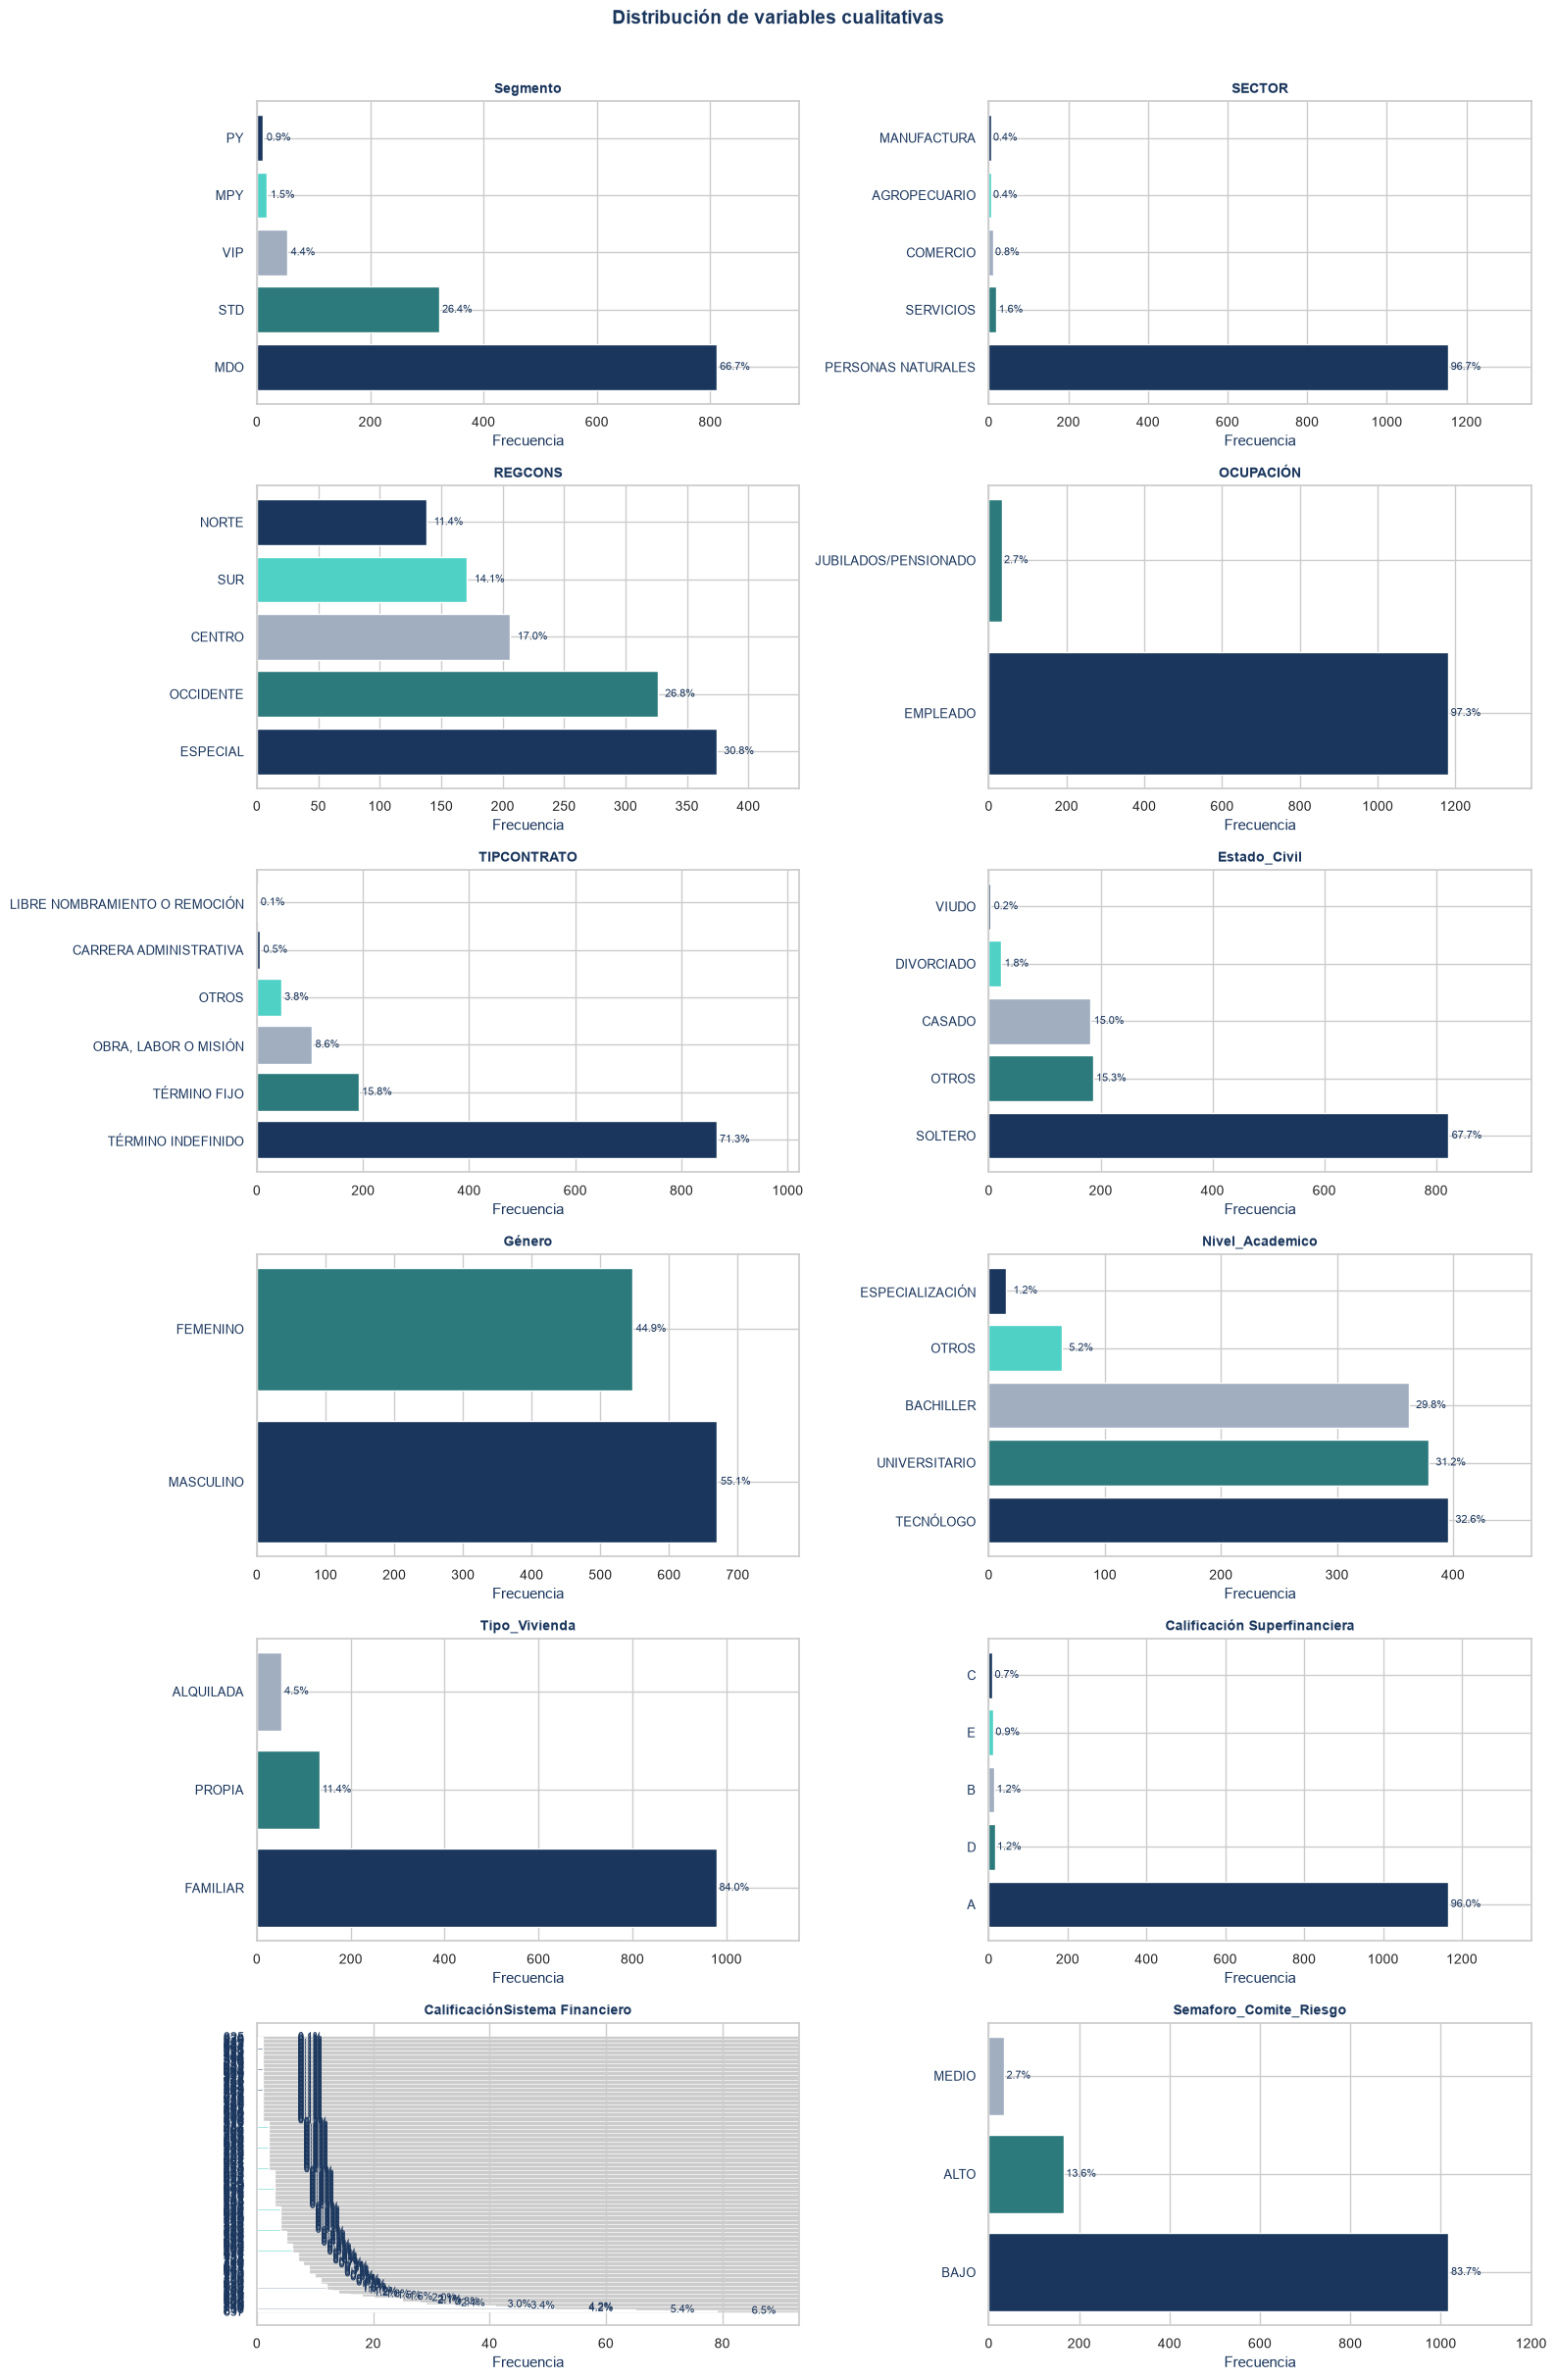

In [16]:
ncols_cat = 2
nrows_cat = int(np.ceil(len(cols_cat) / ncols_cat))
fig, axes = plt.subplots(nrows_cat, ncols_cat, figsize=(16, nrows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    ax = axes[i]
    orden = df[col].value_counts().index.tolist()
    counts = df[col].value_counts().reindex(orden)
    total_col = counts.sum()
    palette_col = [PALETA[index % len(PALETA)] for index in range(len(orden))]
    # barh manual para máxima compatibilidad con cualquier versión de seaborn
    bars = ax.barh(range(len(orden)), counts.values, color=palette_col)
    ax.set_yticks(range(len(orden)))
    ax.set_yticklabels(orden, fontsize=9, color=AZUL)
    ax.set_title(col, fontsize=10, fontweight='bold', color=AZUL)
    ax.set_xlabel('Frecuencia', color=AZUL)
    for bar, val in zip(bars, counts.values):
        pct = val / total_col * 100
        ax.text(bar.get_width() + total_col * 0.005, bar.get_y() + bar.get_height() / 2,
                f'{pct:.1f}%', va='center', fontsize=8, color=AZUL)
    ax.set_xlim(0, counts.max() * 1.18)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de variables cualitativas', fontsize=14, fontweight='bold', color=AZUL, y=1.01)
plt.tight_layout()
plt.show()

## 4.5 — Correlación entre variables cuantitativas


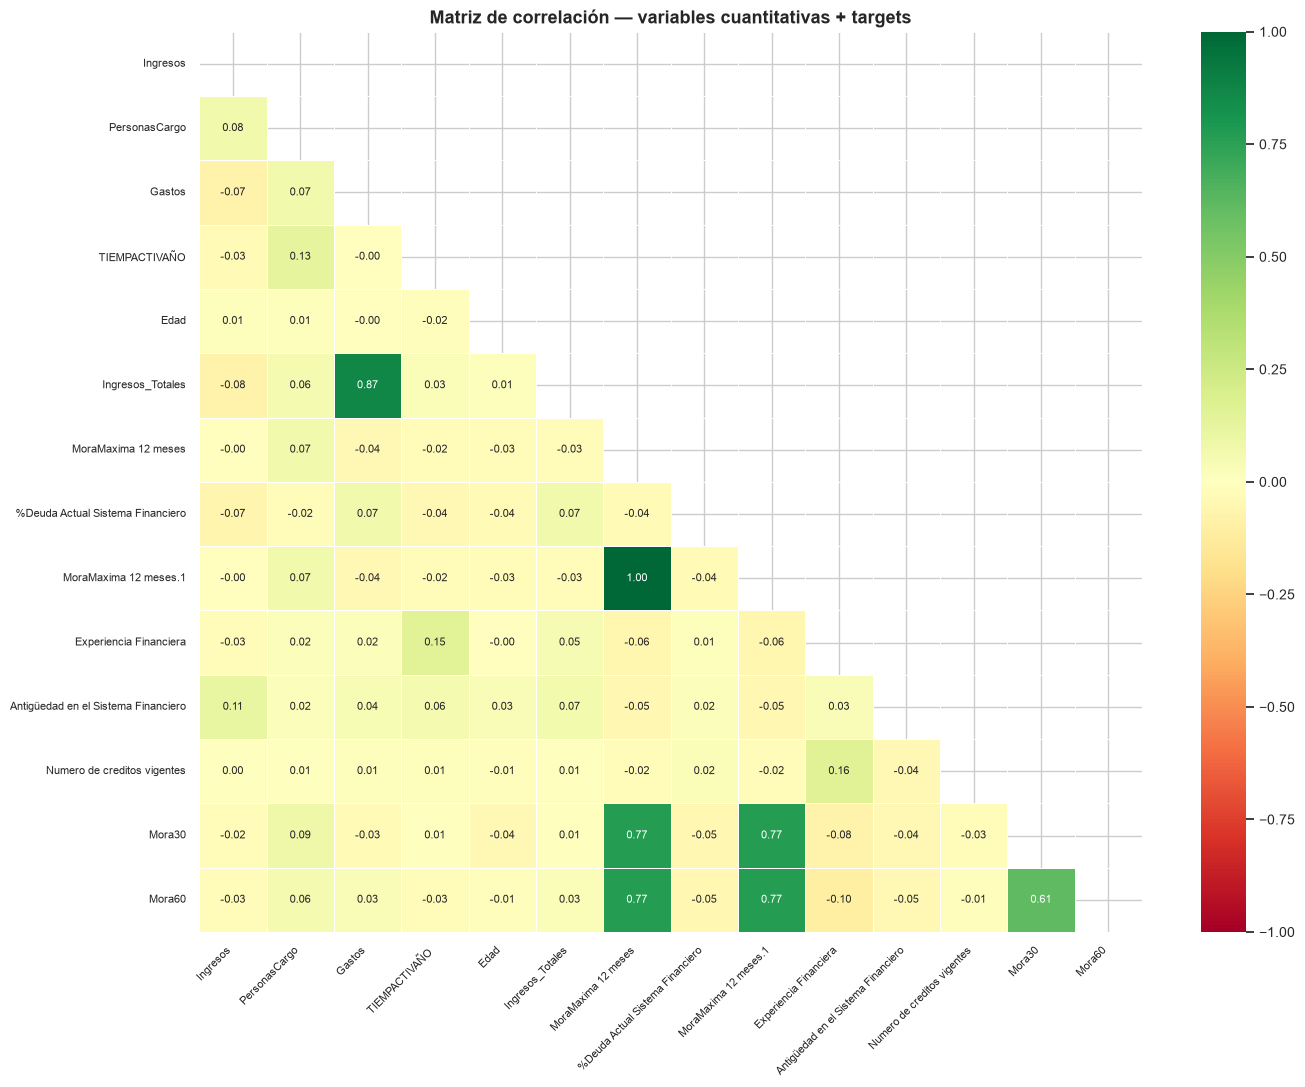

In [9]:
cols_corr = cols_num + TARGETS
corr = df[cols_corr].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # solo triángulo inferior

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.4, ax=ax,
    annot_kws={'size': 8},
    vmin=-1, vmax=1
)
ax.set_title('Matriz de correlación — variables cuantitativas + targets', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


## 4.6 — Variables cuantitativas vs. Mora30 (comparación de distribución por clase)


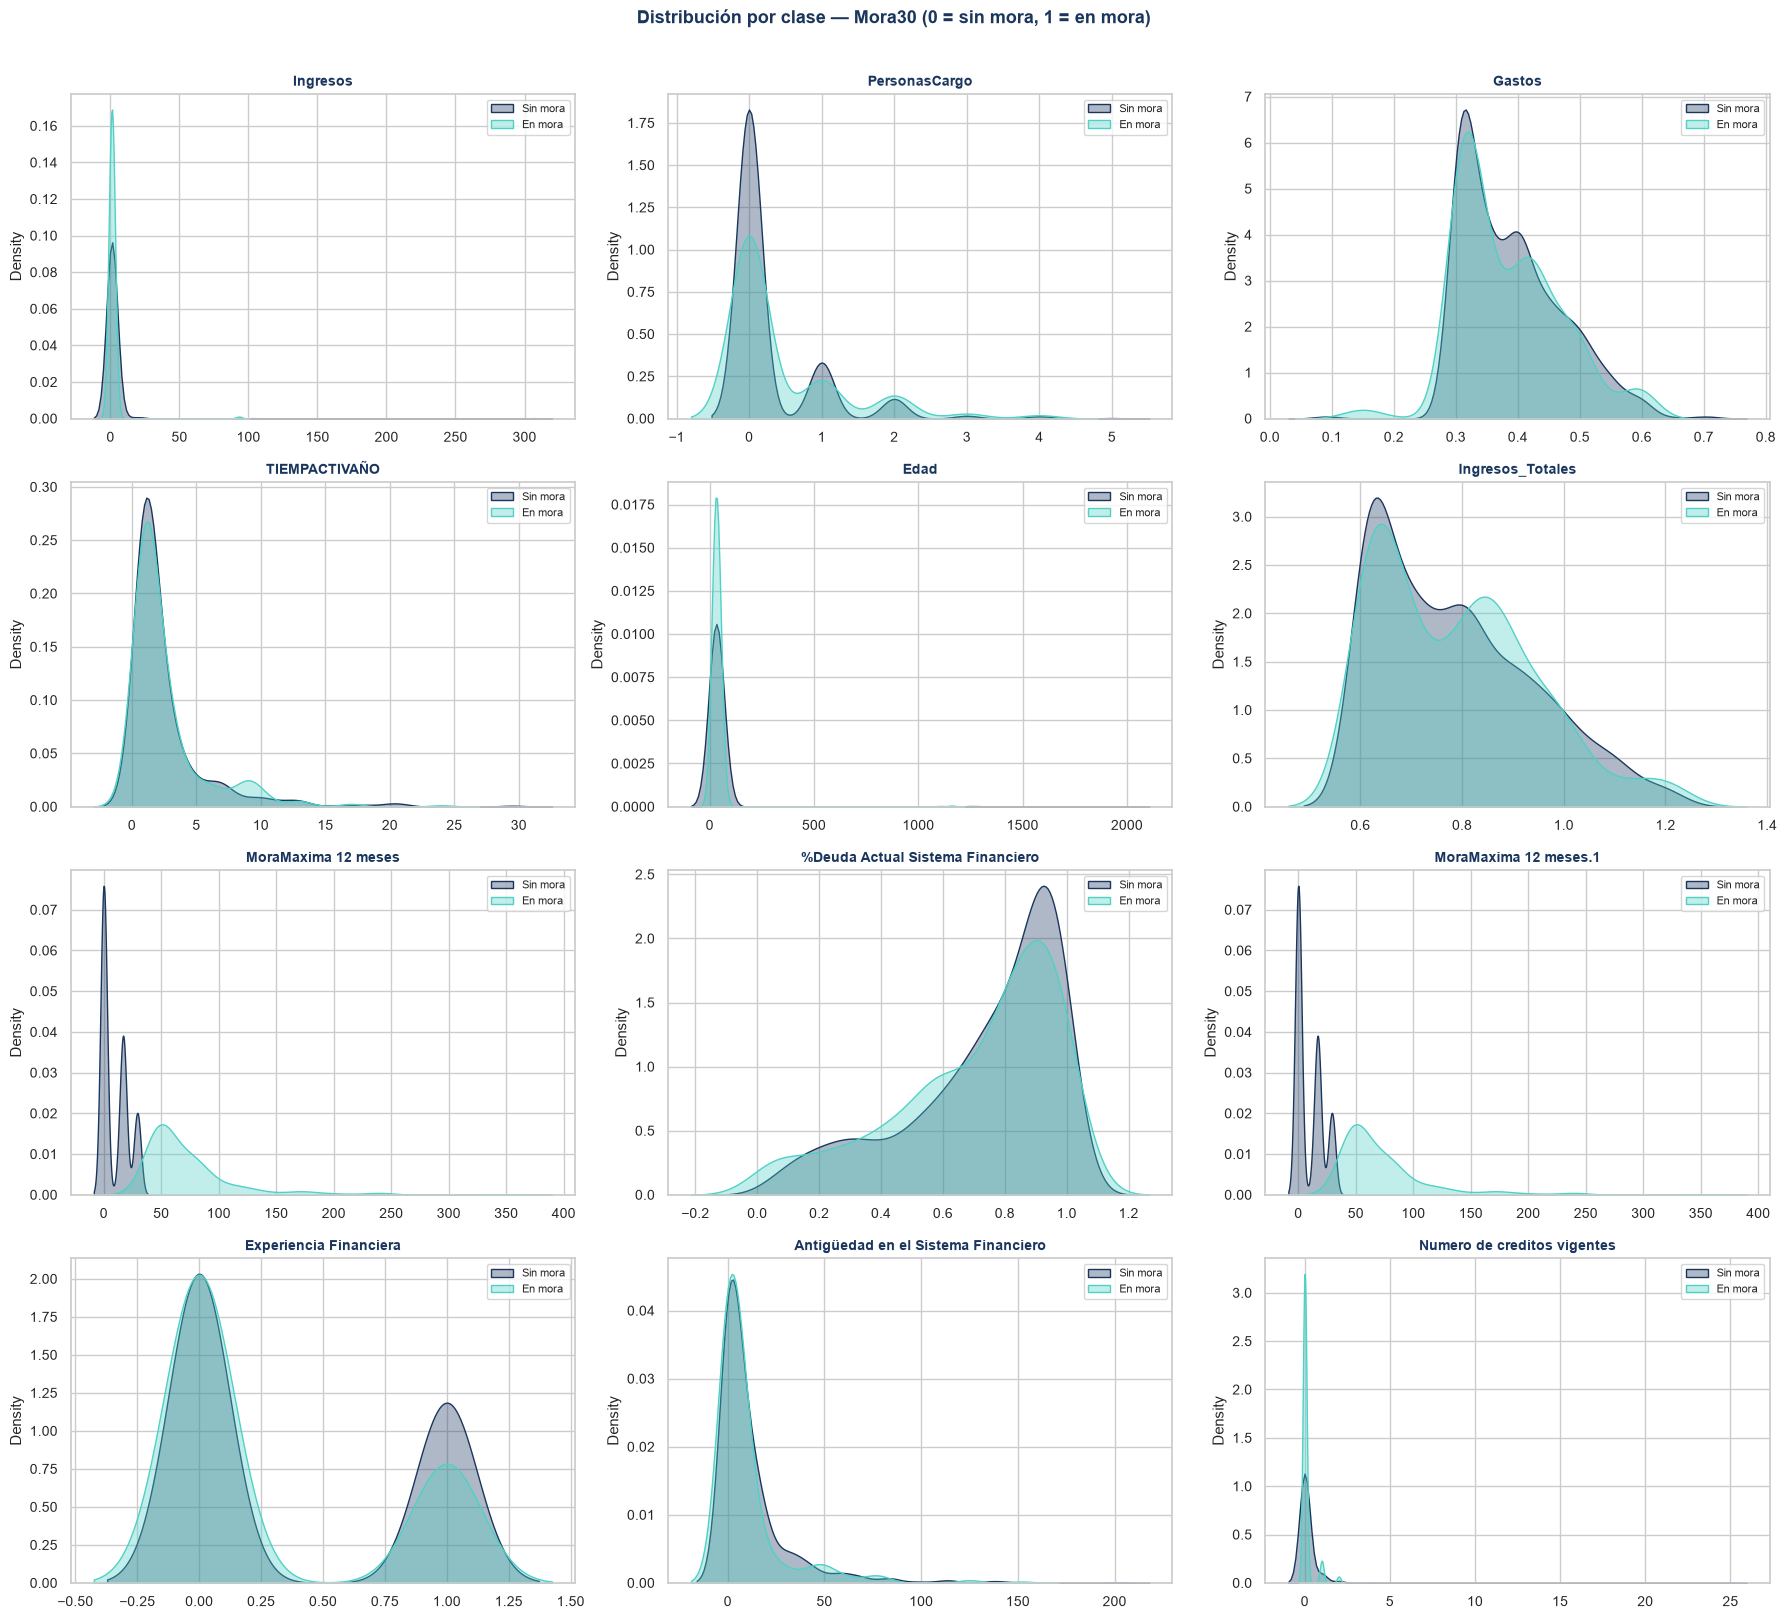

In [20]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    ax = axes[i]
    for val, color, label in [(0, AZUL, 'Sin mora'), (1, TURQUESA, 'En mora')]:
        subset = df[df['Mora30'] == val][col].dropna()
        sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.35, label=label)
    ax.set_title(col, fontsize=10, fontweight='bold', color=AZUL)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución por clase — Mora30 (0 = sin mora, 1 = en mora)', fontsize=13, fontweight='bold', color=AZUL, y=1.01)
plt.tight_layout()
plt.show()